In [16]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


In [23]:
# Load results
results_file = "compound_sim_stability_all_nn_30_30_30.csv"
df = pd.read_csv(results_file)

df_unique = df.drop_duplicates(subset=['impute_seed', 'split_seed', 'train_seed'])[['impute_seed', 'split_seed', 'train_seed', 'mse']].copy()

# Get seed lists
impute_seeds = df_unique['impute_seed'].unique()
split_seeds = df_unique['split_seed'].unique()
train_seeds = df_unique['train_seed'].unique()


# Variance decomposition
overall_variance = df_unique['mse'].var(ddof=1)
overall_mean = df_unique['mse'].mean()
overall_std = df_unique['mse'].std(ddof=1)

# =============================================================================
# Data Preparation for Variance MSE of Compound Simulation Visualization
# =============================================================================

# Variance due to IMPUTATION (holding split AND train fixed)
impute_variances = []
for ss in split_seeds:
    for st in train_seeds:
        subset = df_unique[(df_unique['split_seed'] == ss) & (df_unique['train_seed'] == st)]
        if len(subset) > 1:
            var = subset['mse'].var(ddof=1)
            impute_variances.append(var)

avg_impute_variance = np.mean(impute_variances)

# Variance due to SPLIT (holding impute AND train fixed)
split_variances = []
for si in impute_seeds:
    for st in train_seeds:
        subset = df_unique[(df_unique['impute_seed'] == si) & (df_unique['train_seed'] == st)]
        if len(subset) > 1:
            var = subset['mse'].var(ddof=1)
            split_variances.append(var)

avg_split_variance = np.mean(split_variances)

# Variance due to TRAINING (holding impute AND split fixed)
train_variances = []
for si in impute_seeds:
    for ss in split_seeds:
        subset = df_unique[(df_unique['impute_seed'] == si) & (df_unique['split_seed'] == ss)]
        if len(subset) > 1:
            var = subset['mse'].var(ddof=1)
            train_variances.append(var)

avg_train_variance = np.mean(train_variances)

# Stratified variance: variance across random groups of 100 observations
n_groups = 30
group_size = 90
np.random.seed(42)  # for reproducibility

stratified_variances = []
for _ in range(n_groups):
    # Sample 100 random observations (with replacement)
    sample_indices = np.random.choice(len(df_unique), size=group_size, replace=True)
    sample_mse = df_unique.iloc[sample_indices]['mse'].values
    var = np.var(sample_mse, ddof=1)
    stratified_variances.append(var)

avg_stratified_variance = np.mean(stratified_variances)

# =============================================================================
# Data Preparation for Mean MSE of Compound Simulation Visualization
# =============================================================================

# Convert variance lists to numpy arrays for plotting
impute_var_arr = np.array(impute_variances)
split_var_arr = np.array(split_variances)
train_var_arr = np.array(train_variances)
stratified_var_arr = np.array(stratified_variances)

# Color palette - distinctive colors for each source
colors_new = {
    'Imputation': '#E6AC00',   # gold/amber
    'Split': '#d73027',        # red
    'Training': '#4575b4',     # blue
    'Stratified': '#1a9850',   # green
}

# Calculate mean MSE for each unique seed value (averaging over all other seeds)
impute_means = df_unique.groupby('impute_seed')['mse'].mean().values
split_means = df_unique.groupby('split_seed')['mse'].mean().values
train_means = df_unique.groupby('train_seed')['mse'].mean().values

In [24]:
# =============================================================================
# Data Preparation for Brand ATE Visualization
# =============================================================================

# Load the Brand ATE stability data
brand_file = "brand_ate_stability_all_30_30_30_0.3.csv"
df_brand = pd.read_csv(brand_file)

# Get unique combinations
df_brand_unique = df_brand.drop_duplicates(subset=['impute_seed', 'sample_seed', 'model_seed'])[
    ['impute_seed', 'sample_seed', 'model_seed', 'ate']
].copy()

# Get seed lists
impute_seeds_brand = df_brand_unique['impute_seed'].unique()
sample_seeds_brand = df_brand_unique['sample_seed'].unique()
model_seeds_brand = df_brand_unique['model_seed'].unique()

# Calculate overall stats
overall_mean_brand = df_brand_unique['ate'].mean()
overall_std_brand = df_brand_unique['ate'].std(ddof=1)

# Calculate mean ATE for each unique seed value
impute_means_brand = df_brand_unique.groupby('impute_seed')['ate'].mean().values
sample_means_brand = df_brand_unique.groupby('sample_seed')['ate'].mean().values
model_means_brand = df_brand_unique.groupby('model_seed')['ate'].mean().values

# Color palette
colors_brand = {
    'Imputation': '#E6AC00',   # gold/amber
    'Sample': '#d73027',       # red
    'Model': '#4575b4',        # blue
}

Saved combined seed analysis figure


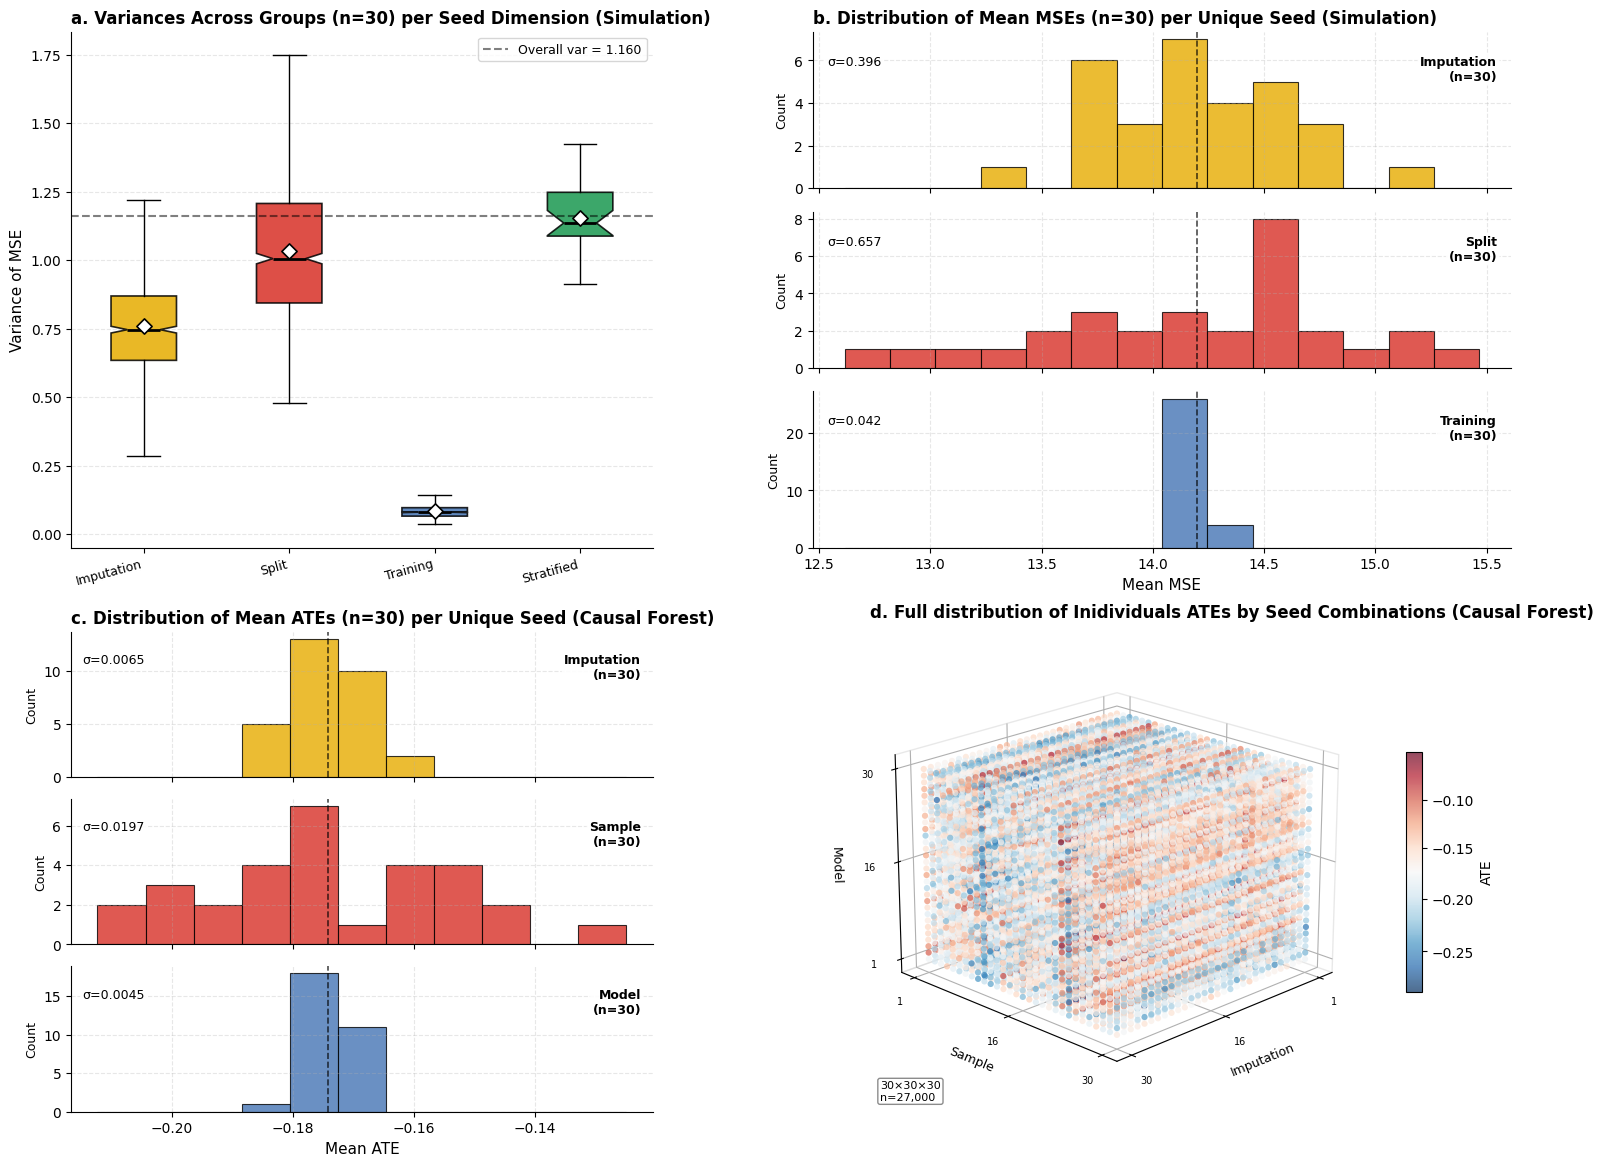

In [25]:
# =============================================================================
# Combined Figure: Top row = Compound Sim (Cell 4), Bottom row = Brand ATE (Cell 5)
# =============================================================================
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import TwoSlopeNorm

# Create figure with 2 rows, 2 columns
fig = plt.figure(figsize=(16, 12))

# Use GridSpec for flexible layout
gs_top = fig.add_gridspec(3, 2, left=0.05, right=0.95, top=0.95, bottom=0.52,
                          width_ratios=[1, 1.2], hspace=0.15, wspace=0.25)
gs_bot = fig.add_gridspec(3, 2, left=0.05, right=0.95, top=0.45, bottom=0.05,
                          width_ratios=[1, 1.2], hspace=0.15, wspace=0.25)

# =============================================================================
# TOP ROW: Compound Simulation (Mean and Variance of MSE)
# =============================================================================

# Top-left: Boxplot of variance distributions
ax_box_top = fig.add_subplot(gs_top[:, 0])

variance_data = [impute_var_arr, split_var_arr, train_var_arr, stratified_var_arr]
labels_top = ['Imputation', 'Split', 'Training', 'Stratified']
palette_top = [colors_new[l] for l in labels_top]

bp = ax_box_top.boxplot(variance_data, tick_labels=labels_top, patch_artist=True, 
                        showfliers=False, notch=True,
                        boxprops=dict(linewidth=1.2),
                        medianprops=dict(linewidth=2.0, color='k'),
                        whiskerprops=dict(linewidth=1.0),
                        capprops=dict(linewidth=1.0))

for patch, color in zip(bp['boxes'], palette_top):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

means_var = [np.mean(v) for v in variance_data]
ax_box_top.scatter(range(1, len(means_var) + 1), means_var, marker='D', s=60, 
                   facecolor='white', edgecolor='k', linewidth=1.2, zorder=3)
ax_box_top.axhline(overall_variance, linestyle='--', linewidth=1.5, 
                   color='k', alpha=0.5, label=f'Overall var = {overall_variance:.3f}')
ax_box_top.set_ylabel('Variance of MSE', fontsize=11)
ax_box_top.set_title('a. Variances Across Groups (n=30) per Seed Dimension (Simulation)', fontsize=12, fontweight='bold', loc='left')
ax_box_top.legend(loc='upper right', frameon=True, fontsize=9)
ax_box_top.grid(axis='y', linestyle='--', alpha=0.3)
ax_box_top.set_xticklabels(labels_top, rotation=15, ha='right', fontsize=9)
sns.despine(ax=ax_box_top)

# Top-right: Histograms of mean MSE
ax_hist_top = [fig.add_subplot(gs_top[i, 1]) for i in range(3)]
for i in range(1, 3):
    ax_hist_top[i].sharex(ax_hist_top[0])

all_means_combined = np.concatenate([impute_means, split_means, train_means])
bins_top = np.linspace(np.min(all_means_combined) - 0.1, np.max(all_means_combined) + 0.1, 15)

hist_data_top = [
    ('Imputation', impute_means, colors_new['Imputation']),
    ('Split', split_means, colors_new['Split']),
    ('Training', train_means, colors_new['Training']),
]

for idx, (name, means_data, color) in enumerate(hist_data_top):
    ax_h = ax_hist_top[idx]
    ax_h.hist(means_data, bins=bins_top, color=color, edgecolor='k', linewidth=0.8, alpha=0.8)
    mean_val = np.mean(means_data)
    std_val = np.std(means_data, ddof=1)
    ax_h.axvline(mean_val, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
    ax_h.text(0.98, 0.85, f'{name}\n(n={len(means_data)})', transform=ax_h.transAxes,
              ha='right', va='top', fontsize=9, fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
    ax_h.text(0.02, 0.85, f'σ={std_val:.3f}', transform=ax_h.transAxes,
              ha='left', va='top', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
    ax_h.set_ylabel('Count', fontsize=9)
    ax_h.grid(axis='both', linestyle='--', alpha=0.3)
    sns.despine(ax=ax_h)
    if idx < 2:
        ax_h.tick_params(axis='x', labelbottom=False)

ax_hist_top[2].set_xlabel('Mean MSE', fontsize=11)
ax_hist_top[0].set_title('b. Distribution of Mean MSEs (n=30) per Unique Seed (Simulation)', fontsize=12, fontweight='bold', loc='left')

# =============================================================================
# BOTTOM ROW: Brand ATE
# =============================================================================

# Bottom-left: Histograms of mean ATE
ax_hist_bot = [fig.add_subplot(gs_bot[i, 0]) for i in range(3)]
for i in range(1, 3):
    ax_hist_bot[i].sharex(ax_hist_bot[0])

all_means_brand = np.concatenate([impute_means_brand, sample_means_brand, model_means_brand])
bins_bot = np.linspace(np.min(all_means_brand) - 0.005, np.max(all_means_brand) + 0.005, 12)

hist_data_bot = [
    ('Imputation', impute_means_brand, colors_brand['Imputation']),
    ('Sample', sample_means_brand, colors_brand['Sample']),
    ('Model', model_means_brand, colors_brand['Model']),
]

for idx, (name, means_data, color) in enumerate(hist_data_bot):
    ax_h = ax_hist_bot[idx]
    ax_h.hist(means_data, bins=bins_bot, color=color, edgecolor='k', linewidth=0.8, alpha=0.8)
    mean_val = np.mean(means_data)
    std_val = np.std(means_data, ddof=1)
    ax_h.axvline(mean_val, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
    ax_h.text(0.98, 0.85, f'{name}\n(n={len(means_data)})', transform=ax_h.transAxes,
              ha='right', va='top', fontsize=9, fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
    ax_h.text(0.02, 0.85, f'σ={std_val:.4f}', transform=ax_h.transAxes,
              ha='left', va='top', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
    ax_h.set_ylabel('Count', fontsize=9)
    ax_h.grid(axis='both', linestyle='--', alpha=0.3)
    sns.despine(ax=ax_h)
    if idx < 2:
        ax_h.tick_params(axis='x', labelbottom=False)

ax_hist_bot[2].set_xlabel('Mean ATE', fontsize=11)
ax_hist_bot[0].set_title('c. Distribution of Mean ATEs (n=30) per Unique Seed (Causal Forest)', fontsize=12, fontweight='bold', loc='left')

# Bottom-right: 3D scatter plot
ax_3d_bot = fig.add_subplot(gs_bot[:, 1], projection='3d')

# Set white background
ax_3d_bot.xaxis.pane.fill = False
ax_3d_bot.yaxis.pane.fill = False
ax_3d_bot.zaxis.pane.fill = False
ax_3d_bot.xaxis.pane.set_edgecolor('lightgray')
ax_3d_bot.yaxis.pane.set_edgecolor('lightgray')
ax_3d_bot.zaxis.pane.set_edgecolor('lightgray')

# Subset to 10x10x10 seeds
n_subset = 30
impute_seeds_subset = sorted(impute_seeds_brand)[:n_subset]
sample_seeds_subset = sorted(sample_seeds_brand)[:n_subset]
model_seeds_subset = sorted(model_seeds_brand)[:n_subset]

df_subset = df_brand_unique[
    (df_brand_unique['impute_seed'].isin(impute_seeds_subset)) &
    (df_brand_unique['sample_seed'].isin(sample_seeds_subset)) &
    (df_brand_unique['model_seed'].isin(model_seeds_subset))
].copy()

impute_seed_to_idx = {seed: i for i, seed in enumerate(impute_seeds_subset)}
sample_seed_to_idx = {seed: i for i, seed in enumerate(sample_seeds_subset)}
model_seed_to_idx = {seed: i for i, seed in enumerate(model_seeds_subset)}

x = df_subset['impute_seed'].map(impute_seed_to_idx).values
y = df_subset['sample_seed'].map(sample_seed_to_idx).values
z = df_subset['model_seed'].map(model_seed_to_idx).values
ate_values = df_subset['ate'].values

vmin, vmax = ate_values.min(), ate_values.max()
vcenter = np.mean(ate_values)
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

scatter = ax_3d_bot.scatter(x, y, z, c=ate_values, cmap='RdBu_r', norm=norm,
                            s=20, alpha=0.7, edgecolors='none')

cbar = fig.colorbar(scatter, ax=ax_3d_bot, shrink=0.5, aspect=15, pad=0.08)
cbar.set_label('ATE', fontsize=10)

ax_3d_bot.set_xlabel('Imputation', fontsize=9, labelpad=5)
ax_3d_bot.set_ylabel('Sample', fontsize=9, labelpad=5)
ax_3d_bot.set_zlabel('Model', fontsize=9, labelpad=5)

tick_positions = [0, n_subset//2, n_subset-1]
ax_3d_bot.set_xticks(tick_positions)
ax_3d_bot.set_yticks(tick_positions)
ax_3d_bot.set_zticks(tick_positions)
ax_3d_bot.set_xticklabels([str(t+1) for t in tick_positions], fontsize=7)
ax_3d_bot.set_yticklabels([str(t+1) for t in tick_positions], fontsize=7)
ax_3d_bot.set_zticklabels([str(t+1) for t in tick_positions], fontsize=7)

ax_3d_bot.view_init(elev=20, azim=45)
ax_3d_bot.set_title('d. Full distribution of Inidividuals ATEs by Seed Combinations (Causal Forest)', fontsize=12, fontweight='bold', loc='left', pad=10)

ax_3d_bot.text2D(0.02, 0.02, f'{n_subset}×{n_subset}×{n_subset}\nn={len(ate_values):,}', 
                 transform=ax_3d_bot.transAxes, fontsize=8, verticalalignment='bottom',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.9))

plt.savefig('../figures/combined_seed_analysis.pdf', bbox_inches='tight')
plt.savefig('../figures/combined_seed_analysis.png', bbox_inches='tight', dpi=300)
print("Saved combined seed analysis figure")
plt.show()
